# Russian River Step 3 -- 2D mesh

Form the 2D mesh, elevate via a DEM, condition.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [3]:
import os,sys
import logging
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import ipywidgets as widgets

import pickle
import shapely
import pandas as pd
import geopandas as gpd
pd.options.display.max_columns = None

import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.condition
import watershed_workflow.dynamic_colormaps

# set the default figure size for notebooks
plt.rcParams["figure.figsize"] = (8, 6)

## Input: Parameters and other source data

In [4]:
# Force Watershed Workflow to pull data from this directory rather than a shared data directory.
# This picks up the Coweeta-specific datasets set up here to avoid large file downloads for 
# demonstration purposes.
#
def splitPathFull(path):
    """
    Splits an absolute path into a list of components such that
    os.path.join(*splitPathFull(path)) == path
    """
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:  # root on Unix or drive letter with backslash on Windows (e.g., C:\)
            parts.insert(0, head)
            break
        elif tail == path:  # just a single file or directory
            parts.insert(0, tail)
            break
        else:
            parts.insert(0, tail)
            path = head
    return parts

cwd = splitPathFull(os.getcwd())
assert cwd[-1] == 'workflow'
cwd = cwd[:-1]

# Note, this directory is where downloaded data will be put as well
data_dir = os.path.join(*(cwd + ['input_data',]))
def toInput(filename):
    return os.path.join(data_dir, filename)

output_dir = os.path.join(*(cwd + ['output_data',]))
output_filenames = dict()
def fromOutput(filename):
    return os.path.join(output_dir, filename)    

def toOutput(role, filename):
    output_filenames[role] = filename
    return fromOutput(filename)

# check output and input dirs exist
if not os.path.isdir(data_dir):
    os.makedirs(data_dir, exist_ok=True)
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)
       

In [5]:
# Set the data directory to the local space to get the locally downloaded files
# REMOVE THIS CELL for general use outside fo Coweeta
watershed_workflow.config.setDataDirectory(data_dir)


In [6]:
## Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed. 
name = 'RussianRiver'
hucs = ['18010110'] # a list of HUCs to run


# -- parameters to clean and reduce the river network prior to meshing
prune_by_area = 20               # km^2
simplify = 200                   # length scale to target average edge 

# -- mesh triangle refinement control
refine_d0 = 200
refine_d1 = 600

refine_L0 = 200
refine_L1 = 500

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2


# Refine triangles if they get too acute
min_angle = 20 # degrees

# width of reach by stream order (order:width)
river_widths = dict({1:10, 2:10, 3:20, 4:30, 5:30}) 


# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.default_crs

## Reload data

In [7]:
with open(fromOutput('03a_watersheds.pickle'), 'rb') as fid:
    watersheds = pickle.load(fid)

reaches = gpd.read_parquet(fromOutput('03a_rivers.parquet'))
rivers = watershed_workflow.river_tree.createRivers(reaches, method='native')


In [8]:
# load m2 mesh from file -- we will use this for testing pitfilling algorithms
with open(fromOutput('03a_m2_no_elevation.pickle'), 'rb') as fid:
    m2 = pickle.load(fid)

## Get a DEM


In [9]:
dem = watershed_workflow.sources.dem_sources['3DEP 30m'].getDataset(watersheds.df.union_all().buffer(500), watersheds.df.crs)['dem']

2026-01-31 10:36:48,170 - root - INFO: Incoming shape area = 0.4208842379541208
2026-01-31 10:36:48,170 - root - INFO: ... buffering incoming shape by three times the native resolution = 0.00162
2026-01-31 10:36:48,171 - root - INFO: ... buffered shape area = 0.4277813454545666
2026-01-31 10:36:48,172 - root - INFO: Getting DEM with map of area = 0.4277813454545666


In [10]:
dem_sm = watershed_workflow.data.smooth2D(dem, 'x', 'y', sigma=10)
diff = dem_sm - dem

Connected callback to axes: Axes(0.0913528,0.0639291;0.260805x0.906071)
Adding non-symmetric group of size 2
... adding a wrapper of type <class 'xarray.core.dataarray.DataArray'>
... adding a wrapper of type <class 'xarray.core.dataarray.DataArray'>
Added a group with 2 wrappers
Now have 1 groups
Adding symmetric group of size 1
... adding a wrapper of type <class 'xarray.core.dataarray.DataArray'>
Added a group with 1 wrappers
Now have 2 groups


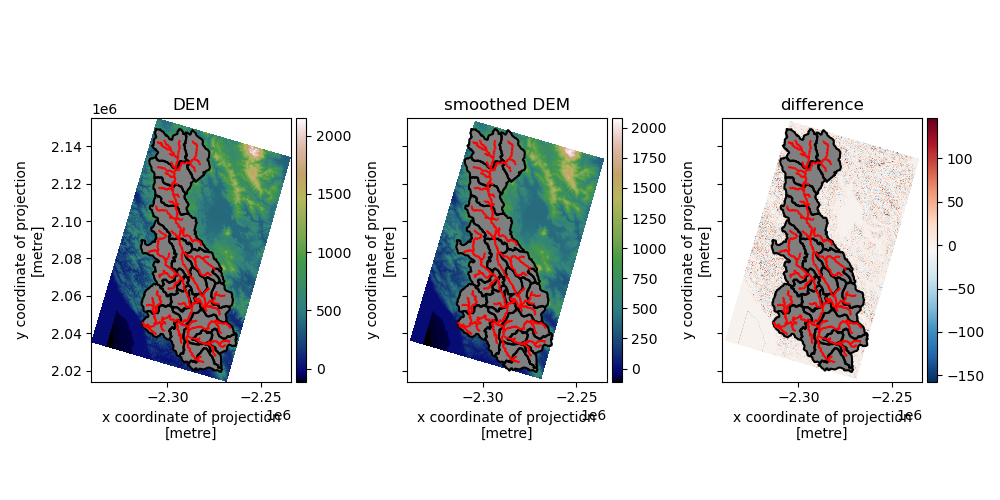

In [36]:
plt.close('all')
del fig
fig, axs = plt.subplots(1,3, sharex=True, sharey=True, figsize=(10,5))

img1 = dem.plot.imshow(cmap='gist_earth', ax=axs[0], vmin=dem.min(), vmax=dem.max(), add_colorbar=False)
axs[0].set_title('DEM')
img2 = dem_sm.plot.imshow(cmap='gist_earth', ax=axs[1], vmin=dem_sm.min(), vmax=dem_sm.max(), add_colorbar=False)
axs[1].set_title('smoothed DEM')
img3 = diff.plot.imshow(cmap='RdBu_r', ax=axs[2], vmin=diff.min(), vmax=diff.max(), add_colorbar=False)
axs[2].set_title('difference')

watersheds.plot(ax=axs[0], color='k')
for river in rivers:
    river.plot(ax=axs[0], color='r')
m2.plot(ax=axs[0], edgecolor='grey', linewidth=0.5, facecolor='none', colorbar=False)
    
watersheds.plot(ax=axs[1], color='k')
for river in rivers:
    river.plot(ax=axs[1], color='r')
m2.plot(ax=axs[1], edgecolor='grey', linewidth=0.5, facecolor='none', colorbar=False)

watersheds.plot(ax=axs[2], color='k')
for river in rivers:
    river.plot(ax=axs[2], color='r')
m2.plot(ax=axs[2], edgecolor='grey', linewidth=0.5, facecolor='none', colorbar=False)

#output = widgets.Output()
output = None
scaler = watershed_workflow.dynamic_colormaps.DynamicColormapScaler(output=output)
scaler.connect(axs[0])
scaler.addGroup([(dem, img1),(dem_sm, img2)], False)
scaler.addGroup([(diff, img3),], True)

#display(output)
for ax, img in zip(axs, [img1, img2, img3]):
    ax.set_aspect('equal', adjustable='box')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(img, cax=cax)
    
fig.canvas.draw()
plt.tight_layout()
plt.show()

## Map DEM to mesh

In [13]:
# raw coordinates
watershed_workflow.elevate(m2, dem)
z_raw = np.copy(m2.coords[:,2])
print(m2.coords[8601,:])
assert not np.any(np.isnan(m2.coords))


[-2.30827921e+06  2.14064643e+06  6.37024719e+02]


In [14]:
# smoothed coordinates
watershed_workflow.elevate(m2, dem_sm)
z_smoothed = np.copy(m2.coords[:,2])
print(m2.coords[8601,:])


[-2308279.206  2140646.432          nan]


In [15]:
# merge the two...
z_combined = np.where(np.isnan(z_smoothed), z_raw, z_smoothed)
print(z_combined[8601])
m2.coords[:,2] = z_combined
assert not np.any(np.isnan(m2.coords))


637.0247192382812


In [16]:
# now deal with the river...
# adding elevations to the river tree for stream bed conditioning
# we use the raw dem here
watershed_workflow.condition.setProfileByDEM(rivers, dem)

In [17]:
for river in rivers:
    for reach in river:
        reach['length'] = reach.linestring.length
for river in rivers:
    river.distribute('length', 0., 'total_length_to_outlet', sum)



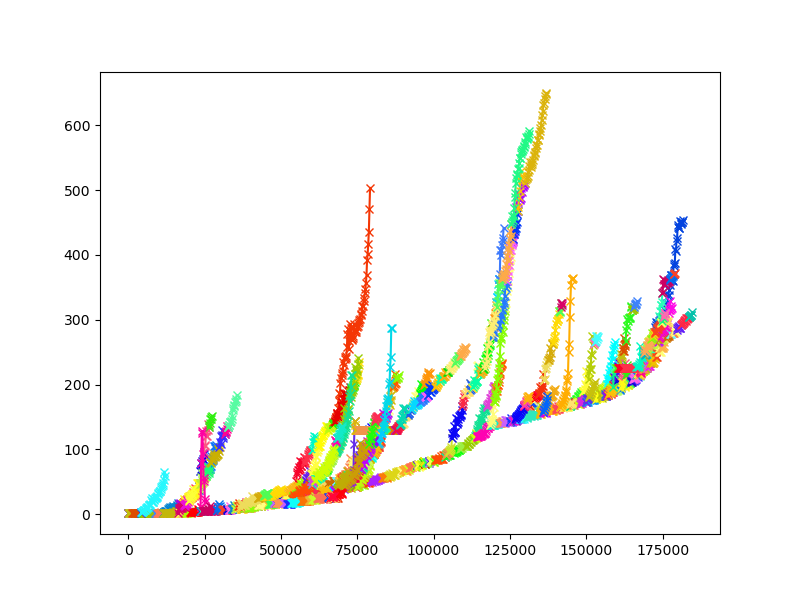

In [18]:
# plot z as a function of x along the river
#
# zooming in shows that the rivers occasionally do not align with the DEM, 
# but jump in and out of the river bank
#
def cumulative_arclength(linestring):
    coords = np.array(linestring.coords)
    
    # Calculate segment lengths
    diffs = np.diff(coords, axis=0)
    segment_lengths = np.sqrt(np.sum(diffs**2, axis=1))
    
    # Prepend 0 and compute cumulative sum
    return np.concatenate([[0], np.cumsum(segment_lengths)])

fig,ax = plt.subplots(1,1)
for reach in rivers[0]:
    s = cumulative_arclength(reach.linestring)
    downstream_s = reach['total_length_to_outlet'] - s
    ax.plot(downstream_s, np.array(reach.linestring.coords)[:,2], '-x')
plt.show()


In [19]:
# now condition the river to fix this, enforcing monotonicity of the river network
def computeBurnInDepth(da_sq_miles):
    """burn-in depth as a function of drainage area"""
    depth_in_feet = 1.22 * da_sq_miles**0.317
    return 0.3048 * depth_in_feet # ft --> meters


def computeBurnInDepthFromReach(reach):
    depth = computeBurnInDepth(reach['drainage_area_sqkm'] * 0.386102)
    logging.debug(f"reach of DA {reach['drainage_area_sqkm']} has depth {depth}")
    return depth
    

watershed_workflow.condition.conditionRiverMeshes(m2,
                       rivers,
                       network_burn_in_depth=computeBurnInDepthFromReach)

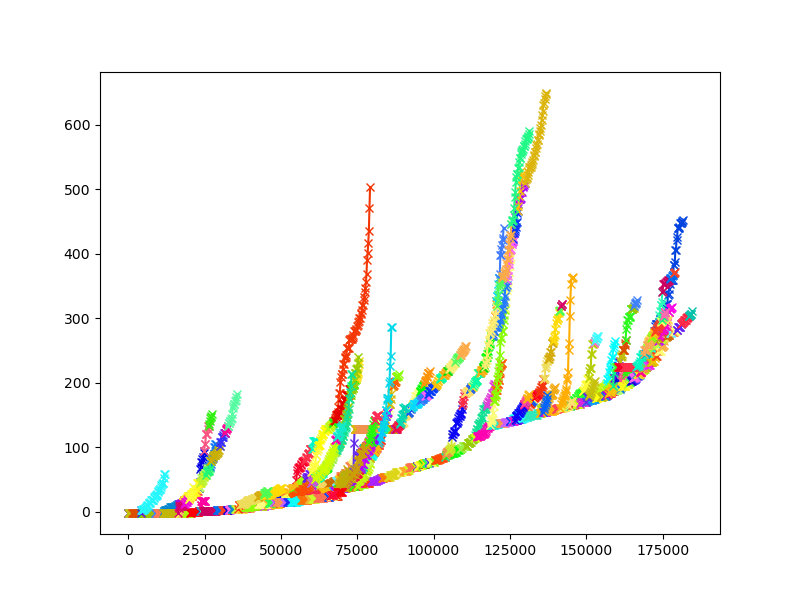

In [20]:
# replot -- look to see if the river got flatter...
fig,ax = plt.subplots(1,1)
for reach in rivers[0]:
    s = cumulative_arclength(reach.linestring)
    downstream_s = reach['total_length_to_outlet'] - s
    ax.plot(downstream_s, np.array(reach.linestring.coords)[:,2], '-x')
plt.show()

In [21]:
assert not (np.isnan(m2.coords)).any()


In [22]:
# save to file -- we will use this for testing pitfilling algorithms
with open(toOutput('03b_m2_preconditioning_smoothed', '03b_m2_preconditioning_smoothed.pickle'), 'wb') as fid:
    pickle.dump(m2, fid)

In [23]:
# the rivers also have extra info now from the conditioning step
river_df = gpd.GeoDataFrame(pd.concat([r.to_dataframe() for r in rivers]), crs=crs)
river_df.to_parquet(toOutput('rivers3', '03b_rivers.parquet'))